# exp20 jon_exp20_canvit_compare_patchers — IN1k top-1 comparison

Loads `results/jon_exp20_canvit_compare_patchers/*_in1k.pt` (one per run), computes per-timestep top-1 accuracy on the 50k ImageNet-1k val set, and shows each run's **unique training params relative to `exp20-base-foveated`** alongside its accuracy curve.

Run names match the wandb run names (= the `RUN_NAME` in each `slurm_nhr/runs/jon_exp20_canvit_compare_patchers/*.sh` script).

In [2]:
from pathlib import Path
import re
import shlex

import torch
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("/user/henrich1/u25995/jonathan/repos/CanViT-eval/results/jon_exp20_canvit_compare_patchers")
SCRIPTS_DIR = Path("/user/henrich1/u25995/jonathan/repos/CanViT-pretrain/slurm_nhr/runs/jon_exp20_canvit_compare_patchers")
BASELINE    = "exp20-base-foveated"
USE_T30 = True  # Set to True to use t30 results, False for normal results


## Load results — per-run per-timestep top-1 accuracy

In [3]:
suffix = "_in1k_t30.pt" if USE_T30 else "_in1k.pt"
results = {}  # run_name -> list[float] (length T = 10, top-1 acc per glimpse)

for path in sorted(RESULTS_DIR.glob(f"*{suffix}")):
    run = path.name.removesuffix(suffix)
    r = torch.load(path, map_location="cpu", weights_only=False)
    preds = r["top_k_preds"].long()      # [N, T, 5]
    labels = r["labels"].long()          # [N]
    top1 = (preds[:, :, 0] == labels[:, None]).float().mean(dim=0).tolist()
    results[run] = top1

T = len(next(iter(results.values())))
print(f"Loaded {len(results)} runs, T={T} glimpses each.")
print(f"Baseline present: {BASELINE in results}")

Loaded 20 runs, T=30 glimpses each.
Baseline present: True


## Parse each run's `EXTRA_ARGS` and diff vs the baseline

We tokenize the `EXTRA_ARGS="..."` line in each run's `.sh` script into `{flag: value}`, then compute the symmetric diff against the baseline. The result is a short, human-readable string per run with only the params that distinguish it from `exp20-base-foveated`.

In [4]:
def parse_extra_args(script_path: Path) -> dict:
    text = script_path.read_text()
    m = re.search(r'^EXTRA_ARGS="([^"]*)"', text, re.M)
    if not m:
        return {}
    tokens = shlex.split(m.group(1))
    args, i = {}, 0
    while i < len(tokens):
        tok = tokens[i]
        if tok.startswith("--"):
            if i + 1 < len(tokens) and not tokens[i + 1].startswith("--"):
                args[tok] = tokens[i + 1]
                i += 2
            else:
                args[tok] = True  # boolean flag
                i += 1
        else:
            i += 1
    return args

run_args = {run: parse_extra_args(SCRIPTS_DIR / f"{run}.sh") for run in results}
baseline_args = run_args[BASELINE]
print(f"Baseline ({BASELINE}):")
for k, v in baseline_args.items():
    print(f"  {k} = {v}")

Baseline (exp20-base-foveated):
  --model.patcher-name = foveated
  --model.foveated-patcher.resolution = 64
  --model.foveated-patcher.cart-patch-size = 8
  --model.foveated-patcher.arch-flag = doubleres


In [5]:
_STRIP_PREFIXES = ("--model.foveated-patcher.", "--model.")

def _short(flag: str) -> str:
    for p in _STRIP_PREFIXES:
        if flag.startswith(p):
            return flag[len(p):]
    return flag.removeprefix("--")

def diff_vs_baseline(args: dict) -> list[str]:
    """Return human-readable list of param differences vs baseline.
    
    Format:
        '+k=v'   : flag k added (not in baseline)
        '+k'     : boolean flag k added
        'k: a→b' : flag k present in both, value changed
        '-k'     : flag k removed (only in baseline)
    """
    diffs = []
    for k, v in args.items():
        if k not in baseline_args:
            diffs.append(f"+{_short(k)}" if v is True else f"+{_short(k)}={v}")
        elif baseline_args[k] != v:
            diffs.append(f"{_short(k)}: {baseline_args[k]}→{v}")
    for k in baseline_args:
        if k not in args:
            diffs.append(f"-{_short(k)}")
    return diffs

run_diffs = {run: diff_vs_baseline(args) for run, args in run_args.items()}

## Summary table

Baseline pinned on top. Other runs sorted by final-glimpse accuracy (descending). The `diff` column shows only what's unique to that run relative to the baseline.

In [6]:
rows = []
for run, top1 in results.items():
    diffs = run_diffs.get(run, [])
    diff_str = "  •  ".join(diffs) if diffs else "(BASELINE)"
    row = {"run": run, "diff_vs_baseline": diff_str, "final": top1[-1], "max": max(top1)}
    for t in range(T):
        row[f"t{t}"] = top1[t]
    rows.append(row)

df = pd.DataFrame(rows)
# pin baseline at top, then sort others by final desc
is_base = df["run"].eq(BASELINE)
df = pd.concat([df[is_base], df[~is_base].sort_values("final", ascending=False)], ignore_index=True)

# delta vs baseline (final-glimpse acc)
baseline_final = df.loc[df["run"] == BASELINE, "final"].iloc[0]
df["delta_final"] = df["final"] - baseline_final

ordered_cols = ["run", "diff_vs_baseline", "final", "max", "delta_final"] + [f"t{t}" for t in range(T)]
df = df[ordered_cols]

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 220)
fmt = {c: "{:+.4f}" if c == "delta_final" else "{:.4f}" for c in ["final", "max", "delta_final"] + [f"t{t}" for t in range(T)]}
df.style.format(fmt).background_gradient(subset=["delta_final"], cmap="RdYlGn", vmin=-0.05, vmax=0.05)

,run,diff_vs_baseline,final,max,delta_final,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,t10,t11,t12,t13,t14,t15,t16,t17,t18,t19,t20,t21,t22,t23,t24,t25,t26,t27,t28,t29
0,exp20-base-foveated,(BASELINE),0.6009,0.6009,+0.0000,0.5196,0.5545,0.5706,0.5784,0.5845,0.5876,0.5894,0.5917,0.5930,0.5938,0.5941,0.5951,0.5958,0.5965,0.5968,0.5976,0.5978,0.5982,0.5986,0.5991,0.5995,0.5995,0.6000,0.6001,0.6005,0.6005,0.6007,0.6005,0.6009,0.6009
1,exp20-uniform16,patcher-name: foveated→uniform • -resolution • -cart-patch-size • -arch-flag,0.7289,0.7310,+0.1280,0.6772,0.7037,0.7150,0.7230,0.7271,0.7280,0.7293,0.7295,0.7298,0.7299,0.7301,0.7296,0.7297,0.7301,0.7300,0.7306,0.7305,0.7307,0.7310,0.7307,0.7308,0.7310,0.7307,0.7305,0.7302,0.7299,0.7297,0.7297,0.7293,0.7289
2,exp20-uniform8,patcher-name: foveated→uniform • +backbone-name=vitb8 • -resolution • -cart-patch-size • -arch-flag,0.7240,0.7259,+0.1231,0.6595,0.6899,0.7026,0.7117,0.7172,0.7189,0.7203,0.7213,0.7225,0.7233,0.7238,0.7241,0.7243,0.7247,0.7247,0.7250,0.7252,0.7252,0.7257,0.7259,0.7257,0.7255,0.7253,0.7250,0.7249,0.7248,0.7245,0.7242,0.7243,0.7240
3,exp20-cond6-strided,patcher-name: foveated→square • +square-patcher.method=strided • +square-patcher.grid-size-fovea=4 • +square-patcher.patch-size=8 • +square-patcher.edge-length-multipliers=4 • +n-backbone-registers=11 • -resolution • -cart-patch-size • -arch-flag,0.6886,0.6894,+0.0877,0.6222,0.6523,0.6646,0.6714,0.6771,0.6797,0.6816,0.6837,0.6847,0.6850,0.6861,0.6864,0.6871,0.6877,0.6878,0.6884,0.6886,0.6887,0.6892,0.6893,0.6892,0.6890,0.6894,0.6892,0.6892,0.6892,0.6891,0.6889,0.6889,0.6886
4,exp20-cond4-square,patcher-name: foveated→square • +square-patcher.method=fovi • +square-patcher.resolution=64 • +square-patcher.cart-patch-size=8 • +square-patcher.no-force-patches-less-than-matched • -resolution • -cart-patch-size • -arch-flag,0.6641,0.6641,+0.0632,0.5854,0.6186,0.6330,0.6424,0.6499,0.6522,0.6535,0.6550,0.6569,0.6579,0.6585,0.6597,0.6605,0.6611,0.6617,0.6617,0.6621,0.6623,0.6623,0.6628,0.6627,0.6630,0.6632,0.6633,0.6632,0.6635,0.6634,0.6639,0.6638,0.6641
5,exp20-cond4-fovi-coordconv-film,+no-force-patches-less-than-matched • +conditioning.mode=coordconv_film • +conditioning.film.input=position • +conditioning.film.fourier.num-features=256 • +conditioning.film.fourier.sigma=4,0.6549,0.6550,+0.0540,0.5680,0.6037,0.6206,0.6301,0.6375,0.6413,0.6434,0.6459,0.6469,0.6482,0.6492,0.6495,0.6507,0.6505,0.6511,0.6521,0.6524,0.6529,0.6528,0.6534,0.6538,0.6543,0.6541,0.6542,0.6545,0.6547,0.6550,0.6548,0.6547,0.6549
6,exp20-cond2-square,patcher-name: foveated→square • +square-patcher.method=fovi • +square-patcher.resolution=49 • +square-patcher.cart-patch-size=6 • +square-patcher.no-force-patches-less-than-matched • -resolution • -cart-patch-size • -arch-flag,0.6548,0.6549,+0.0538,0.5728,0.6073,0.6220,0.6323,0.6383,0.6416,0.6438,0.6451,0.6467,0.6478,0.6489,0.6498,0.6508,0.6514,0.6515,0.6519,0.6527,0.6533,0.6532,0.6537,0.6536,0.6544,0.6545,0.6546,0.6547,0.6544,0.6546,0.6546,0.6549,0.6548
7,exp20-cond3-square,patcher-name: foveated→square • +square-patcher.method=fovi • +square-patcher.resolution=64 • +square-patcher.cart-patch-size=8 • +square-patcher.sample-cortex=False • +square-patcher.no-force-patches-less-than-matched • -resolution • -cart-patch-size • -arch-flag,0.6501,0.6503,+0.0491,0.5778,0.6099,0.6247,0.6324,0.6376,0.6396,0.6420,0.6427,0.6439,0.6447,0.6456,0.6463,0.6468,0.6473,0.6479,0.6489,0.6485,0.6487,0.6490,0.6492,0.6500,0.6497,0.6500,0.6501,0.6503,0.6502,0.6503,0.6503,0.6501,0.6501
8,exp20-cond1-square,patcher-name: foveated→square • +square-patcher.method=fovi • +square-patcher.resolution=49 • +square-patcher.cart-patch-size=6 • +square-patcher.sample-cortex=False • +square-patcher.no-force-patches-less-than-matched • -resolution • -cart-patch-size • -arch-flag,0.6466,0.6466,+0.0457,0.5664,0.6002,0.6158,0.6253,0.6313,0.6343,0.6364,0.6376,0.6393,0.6408,0.6423,0.6431,0.6442,0.6443,0.6450,0.6452,0.6454,0.6459,0.6458,0.6459,0.6463,0.6462,0.6465,

## Δ fovi − reg — per-condition (reg is the baseline)

Same columns as the table above, but every metric cell is `fovi − reg` at that glimpse, for each condition that has both a `-reg` and a `-fovi` variant (cond1–cond4). Here the matching `-reg` run is the baseline (not `exp20-base-foveated`). Green = fovi better than reg, red = worse.

In [7]:
# Δ (fovi − reg) for the conditions that have both a -reg and a -fovi variant.
# Here the matching *reg* run is the baseline for each row (NOT exp20-base-foveated).
pair_conds = sorted({
    m.group(1) for r in results
    if (m := re.match(r"(exp20-cond\d+)-reg$", r)) and f"{m.group(1)}-fovi" in results
})

rows = []
for cond in pair_conds:
    reg, fovi = f"{cond}-reg", f"{cond}-fovi"
    a, b = results[fovi], results[reg]          # delta = fovi − reg
    diffs = run_diffs.get(fovi, [])
    row = {
        "run": f"{cond}: fovi − reg",
        "diff_vs_baseline": "  •  ".join(diffs) if diffs else "(BASELINE)",
        "final": a[-1] - b[-1],
        "max":   max(a) - max(b),
    }
    for t in range(T):
        row[f"t{t}"] = a[t] - b[t]
    rows.append(row)

df_pair = pd.DataFrame(rows)
metric_cols = ["final", "max"] + [f"t{t}" for t in range(T)]
df_pair = df_pair[["run", "diff_vs_baseline"] + metric_cols]

fmt = {c: "{:+.4f}" for c in metric_cols}
df_pair.style.format(fmt).background_gradient(subset=metric_cols, cmap="RdYlGn", vmin=-0.05, vmax=0.05)

,run,diff_vs_baseline,final,max,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,t10,t11,t12,t13,t14,t15,t16,t17,t18,t19,t20,t21,t22,t23,t24,t25,t26,t27,t28,t29
0,exp20-cond1: fovi − reg,resolution: 64→49 • cart-patch-size: 8→6 • +sample-cortex=False • +no-force-patches-less-than-matched,-0.0227,-0.0226,-0.0218,-0.0220,-0.0227,-0.0223,-0.0223,-0.0219,-0.0221,-0.0225,-0.0235,-0.0231,-0.0235,-0.0237,-0.0243,-0.0240,-0.0236,-0.0232,-0.0231,-0.0229,-0.0226,-0.0225,-0.0223,-0.0225,-0.0225,-0.0224,-0.0223,-0.0229,-0.0227,-0.0224,-0.0225,-0.0227
1,exp20-cond2: fovi − reg,resolution: 64→49 • cart-patch-size: 8→6 • +no-force-patches-less-than-matched,-0.0252,-0.0252,-0.0260,-0.0223,-0.0244,-0.0240,-0.0249,-0.0245,-0.0240,-0.0244,-0.0245,-0.0242,-0.0248,-0.0249,-0.0251,-0.0248,-0.0252,-0.0252,-0.0257,-0.0250,-0.0251,-0.0252,-0.0251,-0.0250,-0.0250,-0.0244,-0.0248,-0.0250,-0.0252,-0.0257,-0.0255,-0.0252
2,exp20-cond3: fovi − reg,+sample-cortex=False • +no-force-patches-less-than-matched,-0.0364,-0.0364,-0.0364,-0.0345,-0.0332,-0.0319,-0.0313,-0.0317,-0.0322,-0.0336,-0.0335,-0.0346,-0.0352,-0.0351,-0.0358,-0.0355,-0.0356,-0.0364,-0.0364,-0.0369,-0.0369,-0.0369,-0.0367,-0.0368,-0.0370,-0.0370,-0.0367,-0.0369,-0.0367,-0.0368,-0.0364,-0.0364
3,exp20-cond4: fovi − reg,+no-force-patches-less-than-matched,-0.0158,-0.0160,-0.0225,-0.0182,-0.0170,-0.0153,-0.0136,-0.0142,-0.0136,-0.0141,-0.0141,-0.0145,-0.0148,-0.0151,-0.0157,-0.0153,-0.0160,-0.0158,-0.0156,-0.0154,-0.0155,-0.0162,-0.0160,-0.0163,-0.0155,-0.0156,-0.0156,-0.0162,-0.0159,-0.0161,-0.0161,-0.0158


## Accuracy vs glimpse — line plot

Baseline is drawn thick & black. Other runs are coloured. Hover/click in jupyterlab for legend interaction, or just visually scan for differences from the baseline.

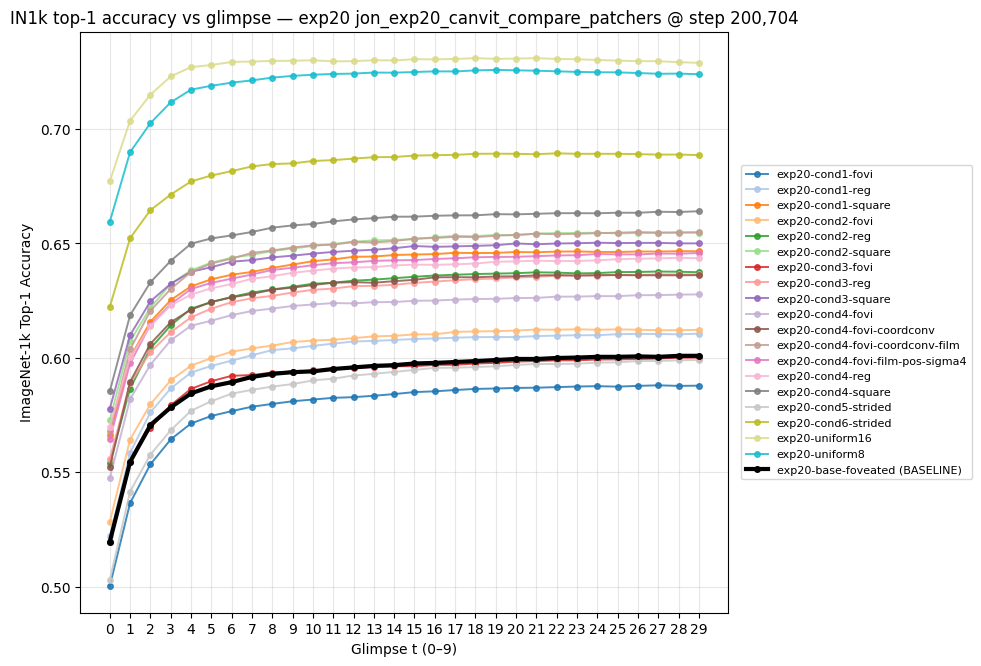

In [8]:
fig, ax = plt.subplots(figsize=(12, 7))
ts = list(range(T))

# tab20 gives 20 perceptually distinct colors so curves never repeat
# (we have up to 20 non-baseline runs -> exact fit).
non_baseline = sorted(r for r in results if r != BASELINE)
# tab20 + tab20b = 40 categorical colors; safe up to 40 non-baseline runs.
_palette = [plt.get_cmap("tab20")(i) for i in range(20)] + [plt.get_cmap("tab20b")(i) for i in range(20)]
color_map = {r: _palette[i % len(_palette)] for i, r in enumerate(non_baseline)}

# Non-baseline first, baseline last so it draws on top.
for run in non_baseline + [BASELINE]:
    is_base = run == BASELINE
    ax.plot(
        ts, results[run], marker="o", markersize=4,
        lw=3 if is_base else 1.4,
        alpha=1.0 if is_base else 0.85,
        color="black" if is_base else color_map[run],
        label=f"{run}{' (BASELINE)' if is_base else ''}",
    )

ax.set_xlabel("Glimpse t (0–9)")
ax.set_ylabel("ImageNet-1k Top-1 Accuracy")
ax.set_title("IN1k top-1 accuracy vs glimpse — exp20 jon_exp20_canvit_compare_patchers @ step 200,704")
ax.set_xticks(ts)
ax.grid(True, alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, borderaxespad=0)

# Explicit subplots_adjust (legend pushed outside via bbox_to_anchor=1.02).
fig.subplots_adjust(left=0.08, right=0.62, top=0.93, bottom=0.10)
plt.show()

## Delta vs baseline — final-glimpse accuracy

Horizontal bar chart of `final_acc(run) − final_acc(baseline)`. Bars right of zero = better than baseline; left = worse.

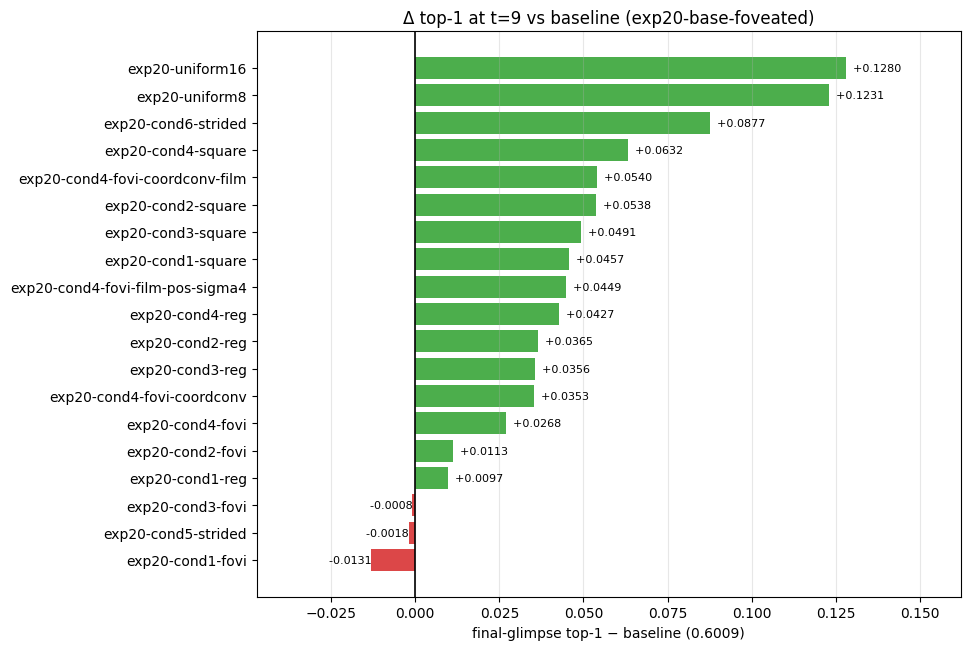

In [9]:
# Self-contained: recompute baseline_final and per-run delta from `results`
# so this cell runs correctly even after a fresh kernel.
baseline_final = results[BASELINE][-1]
deltas = [(r, results[r][-1] - baseline_final) for r in results if r != BASELINE]
deltas.sort(key=lambda x: x[1])
run_names = [r for r, _ in deltas]
delta_vals = [d for _, d in deltas]

# Use INTEGER y-positions everywhere; put run names on as yticklabels.
# Passing a string as the y-arg of ax.text triggers matplotlib's categorical
# unit converter, which on some matplotlib versions returns a numpy array
# (not a scalar) and then errors at draw time ("only 0-dimensional arrays
# can be converted to Python scalars" in text.py: float(convert_yunits(_y))).
y_pos = list(range(len(run_names)))

fig, ax = plt.subplots(figsize=(11, max(4, 0.35 * len(deltas))))
colors = ["#2ca02c" if d >= 0 else "#d62728" for d in delta_vals]
ax.barh(y_pos, delta_vals, color=colors, alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels(run_names)
ax.axvline(0, color="black", lw=1.2)
ax.set_xlabel(f"final-glimpse top-1 − baseline ({baseline_final:.4f})")
ax.set_title("Δ top-1 at t=9 vs baseline (exp20-base-foveated)")
ax.grid(True, alpha=0.3, axis="x")

# Pad xlim so right-side text labels don't get clipped at the edge.
xmin, xmax = ax.get_xlim()
pad = max(abs(xmin), abs(xmax)) * 0.20
ax.set_xlim(xmin - pad, xmax + pad)

for i, d in zip(y_pos, delta_vals):
    ax.text(d, i, f"  {d:+.4f}", va="center", fontsize=8,
            ha="left" if d >= 0 else "right")

fig.subplots_adjust(left=0.32, right=0.96, top=0.93, bottom=0.08)
plt.show()

# Teacher reconstruction (cosine similarity vs DINOv3)

Loads `results/jon_exp20_canvit_compare_patchers/*_recon[_t30].pt` (respects `USE_T30`). Per-glimpse metrics:
- **`scene_cos_norm`** — canvas patch features vs teacher patch features, standardized
- **`cls_cos_norm`** — recurrent CLS vs teacher CLS, standardized

Same baseline (`exp20-base-foveated`) and same `run_diffs` table reused from the in1k section above (extended inline for any recon-only runs).

In [10]:
recon_suffix = "_recon_t30.pt" if USE_T30 else "_recon.pt"
recon_results = {}  # run -> {scene_cos_norm: [t0..tT], cls_cos_norm: [t0..tT]}
for path in sorted(RESULTS_DIR.glob(f"*{recon_suffix}")):
    run = path.name.removesuffix(recon_suffix)
    r = torch.load(path, map_location="cpu", weights_only=False)
    per_t = r["per_timestep"]
    recon_results[run] = {
        "scene_cos_norm": [p["scene_cos_norm"] for p in per_t],
        "cls_cos_norm":   [p["cls_cos_norm"]   for p in per_t],
    }
    # Extend run_diffs for runs that appear in recon but not in in1k (e.g. uniform6/7).
    if run not in run_diffs:
        script = SCRIPTS_DIR / f"{run}.sh"
        if script.exists():
            run_diffs[run] = diff_vs_baseline(parse_extra_args(script))

T_recon = len(next(iter(recon_results.values()))["scene_cos_norm"])
print(f"Loaded {len(recon_results)} recon runs, T={T_recon} glimpses each.")
print(f"Baseline present: {BASELINE in recon_results}")

Loaded 22 recon runs, T=30 glimpses each.
Baseline present: True


## Summary table

Baseline pinned on top; others sorted by `scene_cos_norm @ t=9` (descending). Shows `t=0` and `t=9` for both metrics, with the t=9 deltas vs baseline gradient-coloured red→green.

In [11]:
rows = []
for run in recon_results:
    rr = recon_results[run]
    diffs = run_diffs.get(run, [])
    diff_str = "  •  ".join(diffs) if diffs else "(BASELINE)"
    rows.append({
        "run": run,
        "diff_vs_baseline": diff_str,
        "scene_t0": rr["scene_cos_norm"][0],
        "scene_t9": rr["scene_cos_norm"][-1],
        "cls_t0":   rr["cls_cos_norm"][0],
        "cls_t9":   rr["cls_cos_norm"][-1],
    })

df_recon = pd.DataFrame(rows)
is_base = df_recon["run"].eq(BASELINE)
df_recon = pd.concat(
    [df_recon[is_base], df_recon[~is_base].sort_values("scene_t9", ascending=False)],
    ignore_index=True,
)

bs_scene_t9 = df_recon.loc[df_recon["run"] == BASELINE, "scene_t9"].iloc[0]
bs_cls_t9   = df_recon.loc[df_recon["run"] == BASELINE, "cls_t9"].iloc[0]
df_recon["Δscene_t9"] = df_recon["scene_t9"] - bs_scene_t9
df_recon["Δcls_t9"]   = df_recon["cls_t9"]   - bs_cls_t9

cols = ["run", "diff_vs_baseline", "scene_t0", "scene_t9", "Δscene_t9",
        "cls_t0", "cls_t9", "Δcls_t9"]
df_recon = df_recon[cols]

fmt = {c: ("{:+.4f}" if c.startswith("Δ") else "{:.4f}")
       for c in cols if c not in ("run", "diff_vs_baseline")}
(df_recon.style
    .format(fmt)
    .background_gradient(subset=["Δscene_t9"], cmap="RdYlGn", vmin=-0.05, vmax=0.05)
    .background_gradient(subset=["Δcls_t9"],   cmap="RdYlGn", vmin=-0.05, vmax=0.05))

,run,diff_vs_baseline,scene_t0,scene_t9,Δscene_t9,cls_t0,cls_t9,Δcls_t9
0,exp20-base-foveated,(BASELINE),0.6050,0.7033,+0.0000,0.6040,0.6704,+0.0000
1,exp20-uniform16,patcher-name: foveated→uniform • -resolution • -cart-patch-size • -arch-flag,0.7373,0.7747,+0.0714,0.7185,0.7601,+0.0897
2,exp20-uniform8,patcher-name: foveated→uniform • +backbone-name=vitb8 • -resolution • -cart-patch-size • -arch-flag,0.7295,0.7704,+0.0671,0.7048,0.7541,+0.0837
3,exp20-uniform7,patcher-name: foveated→uniform • +backbone-name=vitb7 • -resolution • -cart-patch-size • -arch-flag,0.7221,0.7677,+0.0644,0.6973,0.7488,+0.0784
4,exp20-uniform6,patcher-name: foveated→uniform • +backbone-name=vitb6 • -resolution • -cart-patch-size • -arch-flag,0.7135,0.7606,+0.0573,0.6849,0.7403,+0.0699
5,exp20-cond6-strided,patcher-name: foveated→square • +square-patcher.method=strided • +square-patcher.grid-size-fovea=4 • +square-patcher.patch-size=8 • +square-patcher.edge-length-multipliers=4 • +n-backbone-registers=11 • -resolution • -cart-patch-size • -arch-flag,0.6814,0.7569,+0.0536,0.6809,0.7308,+0.0604
6,exp20-cond4-square,patcher-name: foveated→square • +square-patcher.method=fovi • +square-patcher.resolution=64 • +square-patcher.cart-patch-size=8 • +square-patcher.no-force-patches-less-than-matched • -resolution • -cart-patch-size • -arch-flag,0.6417,0.7395,+0.0362,0.6538,0.7171,+0.0467
7,exp20-cond2-square,patcher-name: foveated→square • +square-patcher.method=fovi • +square-patcher.resolution=49 • +square-patcher.cart-patch-size=6 • +square-patcher.no-force-patches-less-than-matched • -resolution • -cart-patch-size • -arch-flag,0.6318,0.7350,+0.0317,0.6441,0.7086,+0.0382
8,exp20-cond4-fovi-coordconv-film,+no-force-patches-less-than-matched • +conditioning.mode=coordconv_film • +conditioning.film.input=position • +conditioning.film.fourier.num-features=256 • +conditioning.film.fourier.sigma=4,0.6308,0.7305,+0.0272,0.6389,0.7059,+0.0355
9,exp20-cond4-reg,patcher-name: foveated→square • +square-patcher.method=fovi_regularized • +square-patcher.resolution=64 • +square-patcher.cart-patch-size=8 • +square-patcher.no-force-patches-less-than-matched • +square-patcher.m-override=10 • +square-patcher.strict-nest-when-possible • -resolution • -cart-patch-size • -arch-flag,0.6349,0.7302,+0.0269,0.6411,0.7021,+0.0317


## Δ fovi − reg — per-condition (reg is the baseline)

Same columns as the recon table above, but every metric cell is `fovi − reg`, for each condition that has both a `-reg` and a `-fovi` variant (cond1–cond4). The matching `-reg` run is the baseline. Green = fovi better than reg, red = worse.

In [12]:
# Δ (fovi − reg) for the conditions with both a -reg and a -fovi recon run.
# The matching *reg* run is the baseline for each row.
pair_conds_r = sorted({
    m.group(1) for r in recon_results
    if (m := re.match(r"(exp20-cond\d+)-reg$", r)) and f"{m.group(1)}-fovi" in recon_results
})

rows = []
for cond in pair_conds_r:
    reg, fovi = f"{cond}-reg", f"{cond}-fovi"
    a, b = recon_results[fovi], recon_results[reg]   # delta = fovi − reg
    diffs = run_diffs.get(fovi, [])
    rows.append({
        "run": f"{cond}: fovi − reg",
        "diff_vs_baseline": "  •  ".join(diffs) if diffs else "(BASELINE)",
        "scene_t0": a["scene_cos_norm"][0]  - b["scene_cos_norm"][0],
        "scene_t9": a["scene_cos_norm"][-1] - b["scene_cos_norm"][-1],
        "cls_t0":   a["cls_cos_norm"][0]    - b["cls_cos_norm"][0],
        "cls_t9":   a["cls_cos_norm"][-1]   - b["cls_cos_norm"][-1],
    })

df_pair_recon = pd.DataFrame(rows)
metric_cols = ["scene_t0", "scene_t9", "cls_t0", "cls_t9"]
df_pair_recon = df_pair_recon[["run", "diff_vs_baseline"] + metric_cols]

fmt = {c: "{:+.4f}" for c in metric_cols}
(df_pair_recon.style
    .format(fmt)
    .background_gradient(subset=metric_cols, cmap="RdYlGn", vmin=-0.05, vmax=0.05))

,run,diff_vs_baseline,scene_t0,scene_t9,cls_t0,cls_t9
0,exp20-cond1: fovi − reg,resolution: 64→49 • cart-patch-size: 8→6 • +sample-cortex=False • +no-force-patches-less-than-matched,-0.0155,-0.0136,-0.0208,-0.0184
1,exp20-cond2: fovi − reg,resolution: 64→49 • cart-patch-size: 8→6 • +no-force-patches-less-than-matched,-0.0115,-0.0143,-0.0202,-0.0210
2,exp20-cond3: fovi − reg,+sample-cortex=False • +no-force-patches-less-than-matched,-0.0234,-0.0239,-0.0282,-0.0283
3,exp20-cond4: fovi − reg,+no-force-patches-less-than-matched,-0.0149,-0.0133,-0.0168,-0.0149


## Progression vs glimpse — line plots

Left: `scene_cos_norm` vs t. Right: `cls_cos_norm` vs t. Baseline thick & black, other runs coloured (`tab20`).

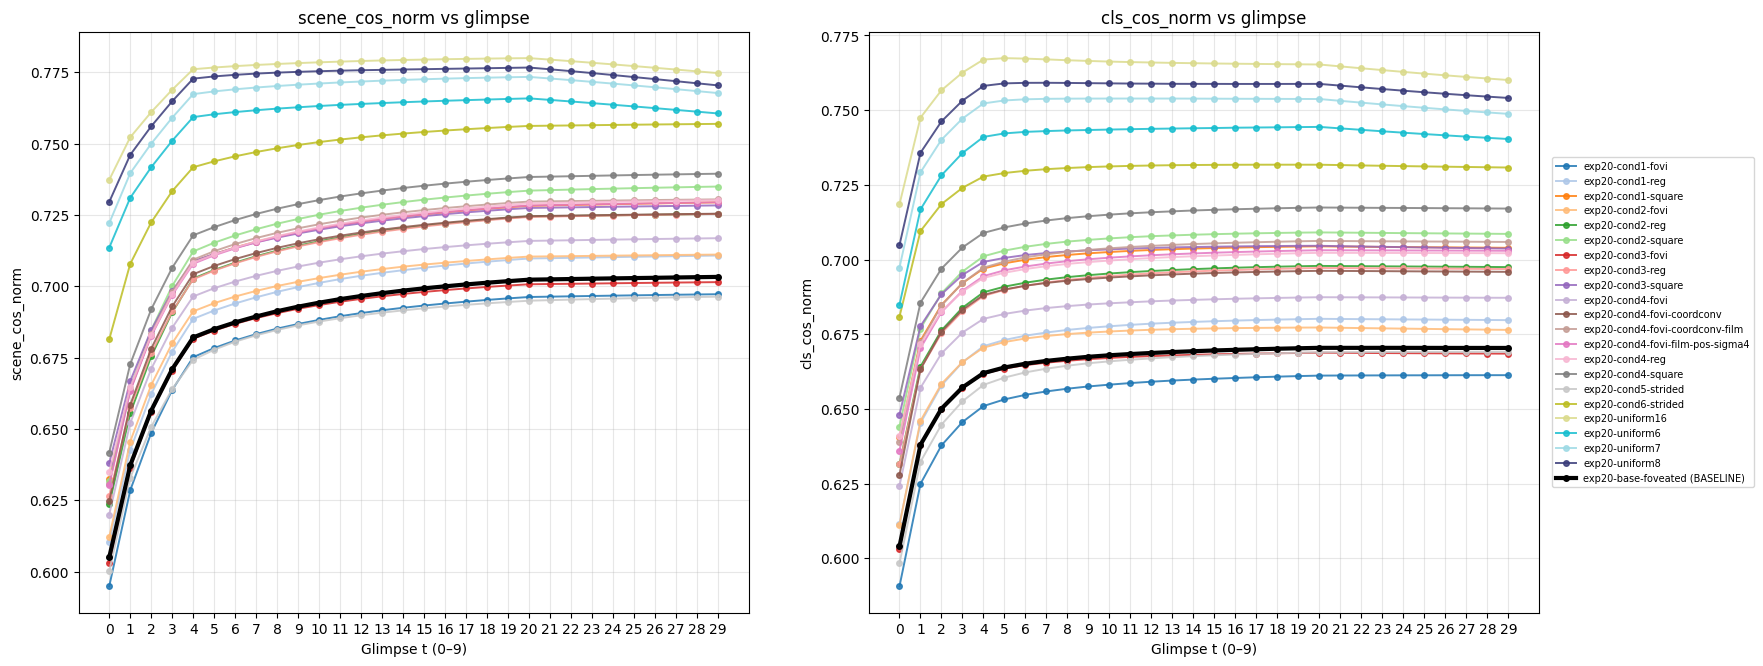

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
ts = list(range(T_recon))

non_baseline_r = sorted(r for r in recon_results if r != BASELINE)
# tab20 + tab20b = 40 categorical colors; safe up to 40 non-baseline runs.
_palette_r = [plt.get_cmap("tab20")(i) for i in range(20)] + [plt.get_cmap("tab20b")(i) for i in range(20)]
color_map_r = {r: _palette_r[i % len(_palette_r)] for i, r in enumerate(non_baseline_r)}

for ax, key, title in [
    (axes[0], "scene_cos_norm", "scene_cos_norm vs glimpse"),
    (axes[1], "cls_cos_norm",   "cls_cos_norm vs glimpse"),
]:
    for run in non_baseline_r + [BASELINE]:
        is_base = run == BASELINE
        ax.plot(
            ts, recon_results[run][key], marker="o", markersize=4,
            lw=3 if is_base else 1.4,
            alpha=1.0 if is_base else 0.85,
            color="black" if is_base else color_map_r[run],
            label=f"{run}{' (BASELINE)' if is_base else ''}",
        )
    ax.set_xlabel("Glimpse t (0–9)")
    ax.set_ylabel(key)
    ax.set_title(title)
    ax.set_xticks(ts)
    ax.grid(True, alpha=0.3)

axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=7, borderaxespad=0)
fig.subplots_adjust(left=0.05, right=0.78, top=0.93, bottom=0.10, wspace=0.18)
plt.show()

## Δ vs baseline at t=9 — horizontal bars

Same idea as the in1k delta plot, separately for the two reconstruction metrics. Green = better than baseline, red = worse. Integer y-positions used to avoid the matplotlib 3.9 categorical-y rendering bug.

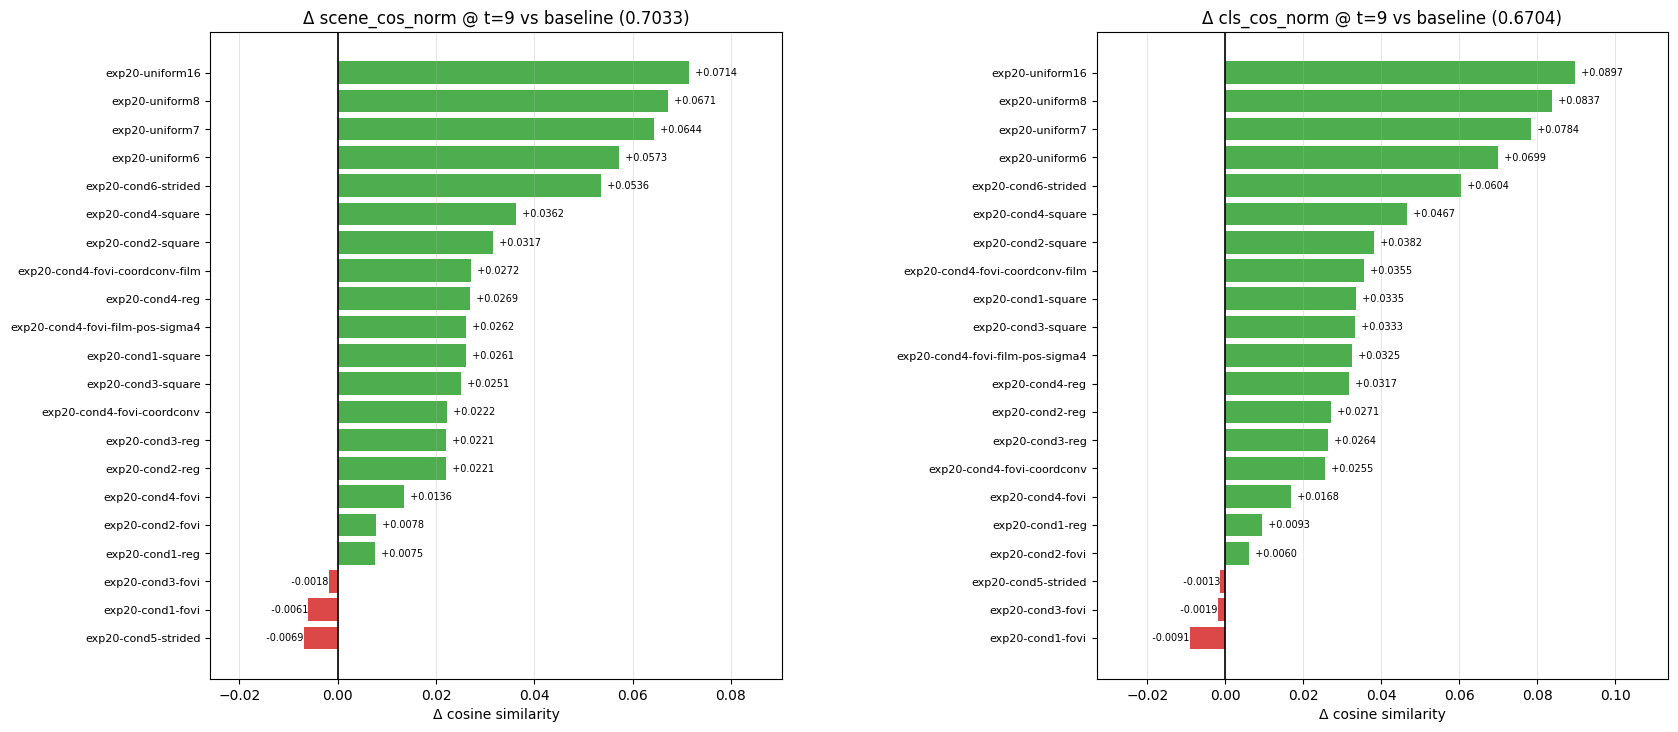

In [14]:
bs_scene = recon_results[BASELINE]["scene_cos_norm"][-1]
bs_cls   = recon_results[BASELINE]["cls_cos_norm"][-1]

scene_deltas = sorted(
    [(r, recon_results[r]["scene_cos_norm"][-1] - bs_scene)
     for r in recon_results if r != BASELINE],
    key=lambda x: x[1],
)
cls_deltas = sorted(
    [(r, recon_results[r]["cls_cos_norm"][-1] - bs_cls)
     for r in recon_results if r != BASELINE],
    key=lambda x: x[1],
)

fig, axes = plt.subplots(1, 2, figsize=(18, max(5, 0.35 * len(scene_deltas))))

for ax, deltas, title in [
    (axes[0], scene_deltas, f"Δ scene_cos_norm @ t=9 vs baseline ({bs_scene:.4f})"),
    (axes[1], cls_deltas,   f"Δ cls_cos_norm @ t=9 vs baseline ({bs_cls:.4f})"),
]:
    names = [r for r, _ in deltas]
    vals  = [d for _, d in deltas]
    y_pos = list(range(len(names)))
    colors = ["#2ca02c" if d >= 0 else "#d62728" for d in vals]
    ax.barh(y_pos, vals, color=colors, alpha=0.85)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=8)
    ax.axvline(0, color="black", lw=1.2)
    ax.set_title(title)
    ax.set_xlabel("Δ cosine similarity")
    ax.grid(True, alpha=0.3, axis="x")
    xmin, xmax = ax.get_xlim()
    pad = max(abs(xmin), abs(xmax)) * 0.20
    ax.set_xlim(xmin - pad, xmax + pad)
    for i, d in zip(y_pos, vals):
        ax.text(d, i, f"  {d:+.4f}", va="center", fontsize=7,
                ha="left" if d >= 0 else "right")

fig.subplots_adjust(left=0.16, right=0.97, top=0.93, bottom=0.05, wspace=0.55)
plt.show()

## Δ vs baseline at t=0 — first-glimpse view

Same chart as above, but using the t=0 cosine instead of t=9. Shows differences in the *initial* (single full-scene glimpse) representation — useful for separating "better at first-look" from "better after sequence integration".

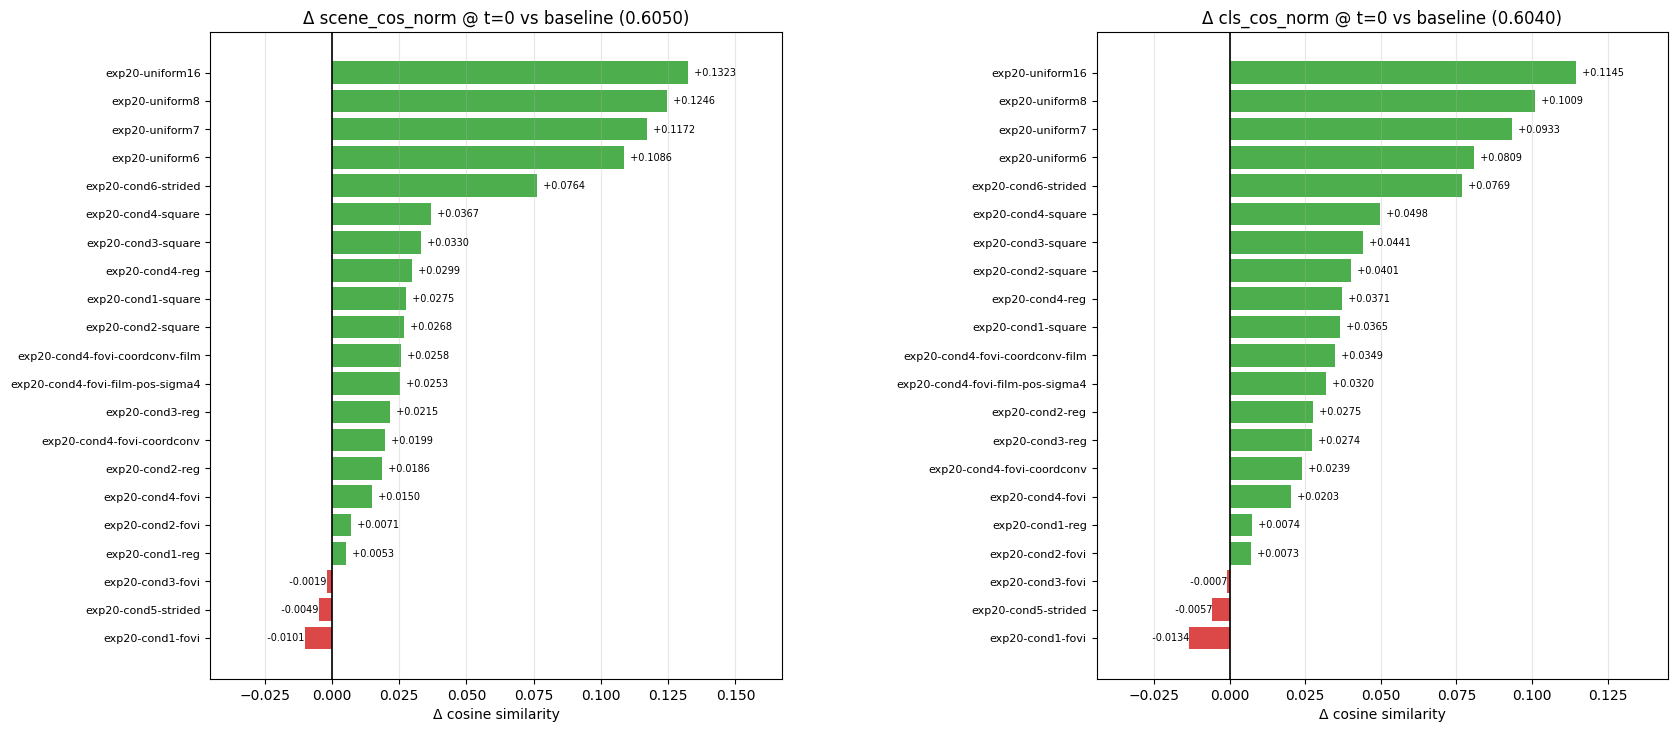

In [15]:
bs_scene_0 = recon_results[BASELINE]["scene_cos_norm"][0]
bs_cls_0   = recon_results[BASELINE]["cls_cos_norm"][0]

scene_deltas_0 = sorted(
    [(r, recon_results[r]["scene_cos_norm"][0] - bs_scene_0)
     for r in recon_results if r != BASELINE],
    key=lambda x: x[1],
)
cls_deltas_0 = sorted(
    [(r, recon_results[r]["cls_cos_norm"][0] - bs_cls_0)
     for r in recon_results if r != BASELINE],
    key=lambda x: x[1],
)

fig, axes = plt.subplots(1, 2, figsize=(18, max(5, 0.35 * len(scene_deltas_0))))

for ax, deltas, title in [
    (axes[0], scene_deltas_0, f"Δ scene_cos_norm @ t=0 vs baseline ({bs_scene_0:.4f})"),
    (axes[1], cls_deltas_0,   f"Δ cls_cos_norm @ t=0 vs baseline ({bs_cls_0:.4f})"),
]:
    names = [r for r, _ in deltas]
    vals  = [d for _, d in deltas]
    y_pos = list(range(len(names)))
    colors = ["#2ca02c" if d >= 0 else "#d62728" for d in vals]
    ax.barh(y_pos, vals, color=colors, alpha=0.85)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=8)
    ax.axvline(0, color="black", lw=1.2)
    ax.set_title(title)
    ax.set_xlabel("Δ cosine similarity")
    ax.grid(True, alpha=0.3, axis="x")
    xmin, xmax = ax.get_xlim()
    pad = max(abs(xmin), abs(xmax)) * 0.20
    ax.set_xlim(xmin - pad, xmax + pad)
    for i, d in zip(y_pos, vals):
        ax.text(d, i, f"  {d:+.4f}", va="center", fontsize=7,
                ha="left" if d >= 0 else "right")

fig.subplots_adjust(left=0.16, right=0.97, top=0.93, bottom=0.05, wspace=0.55)
plt.show()